In [1]:
import pandas as pd
data = pd.read_csv('Linkedin_dataset.csv', engine = 'python',on_bad_lines='skip')
df = pd.DataFrame(data)
df.head()

,title,description,skills
0,Data Science Director,Altoida is a pioneer in developing digital bio...,['Generative ML methods' 'Discriminative ML me...
1,Senior Data Scientist,Veeva Systems is a mission-driven organization...,['Natural Language Processing (NLP)' 'Machine ...
2,Staff Data Scientist,"To get the best candidate experience, please c...",['SQL' 'Programming language for data analysis...
3,Sr Staff Data Scientist Ecosystem,About Pinterest: Millions of people across the...,['Quantitative modeling' 'Experimentation desi...
4,Staff Data Scientist Growth,About Pinterest: Millions of people across the...,['Scientific Methods' 'Web-scale Data Analysis...


In [2]:
df.shape

(420, 3)

In [3]:
df.isna().sum()

,0
title,0
description,0
skills,0


In [4]:
df.title.nunique()

262

In [5]:
df['job_text'] = df['title'] + " " + df['description'] + " " + df['skills']

In [6]:
df.job_text.head()

,job_text
0,Data Science Director Altoida is a pioneer in ...
1,Senior Data Scientist Veeva Systems is a missi...
2,Staff Data Scientist To get the best candidate...
3,Sr Staff Data Scientist Ecosystem About Pinter...
4,Staff Data Scientist Growth About Pinterest: M...


In [7]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [8]:
stopwords = stopwords.words('english')

In [9]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [10]:
from nltk.stem import WordNetLemmatizer
import re
lemmatizer = WordNetLemmatizer()

In [11]:
df['job_text'].isna().sum()

np.int64(0)

In [12]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'https\s+', ' ', text)
  text = re.sub(r'www\s+', ' ',text)
  text = re.sub(r'\s+@\s+',' ',text)
  text = re.sub(r'[^a-zA-z ]',' ',text)
  words = text.split()
  words = [lemmatizer.lemmatize(word) for word in words if word not in stopwords]
  return " ".join(words)

In [13]:
df['job_text'] = df['job_text'].apply(clean_text)

In [14]:
df.job_text.head()

,job_text
0,data science director altoida pioneer developi...
1,senior data scientist veeva system mission dri...
2,staff data scientist get best candidate experi...
3,sr staff data scientist ecosystem pinterest mi...
4,staff data scientist growth pinterest million ...


In [15]:
df.job_text.shape

(420,)

In [16]:
x = df['job_text']

In [19]:
df.head()

,title,description,skills,job_text
0,Data Science Director,Altoida is a pioneer in developing digital bio...,['Generative ML methods' 'Discriminative ML me...,data science director altoida pioneer developi...
1,Senior Data Scientist,Veeva Systems is a mission-driven organization...,['Natural Language Processing (NLP)' 'Machine ...,senior data scientist veeva system mission dri...
2,Staff Data Scientist,"To get the best candidate experience, please c...",['SQL' 'Programming language for data analysis...,staff data scientist get best candidate experi...
3,Sr Staff Data Scientist Ecosystem,About Pinterest: Millions of people across the...,['Quantitative modeling' 'Experimentation desi...,sr staff data scientist ecosystem pinterest mi...
4,Staff Data Scientist Growth,About Pinterest: Millions of people across the...,['Scientific Methods' 'Web-scale Data Analysis...,staff data scientist growth pinterest million ...


In [20]:

from google.colab import files
df.to_csv('04_Clustering_dataset.csv', index = False)
files.download('04_Clustering_dataset.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features = 10000,
    ngram_range = (1,3)
)

In [22]:
x = tfidf.fit_transform(x)

In [23]:
x.shape

(420, 10000)

Elbow


In [24]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,15):
  kmeans = KMeans(n_clusters=k, random_state = 42)
  kmeans.fit(x)
  inertia.append(kmeans.inertia_)

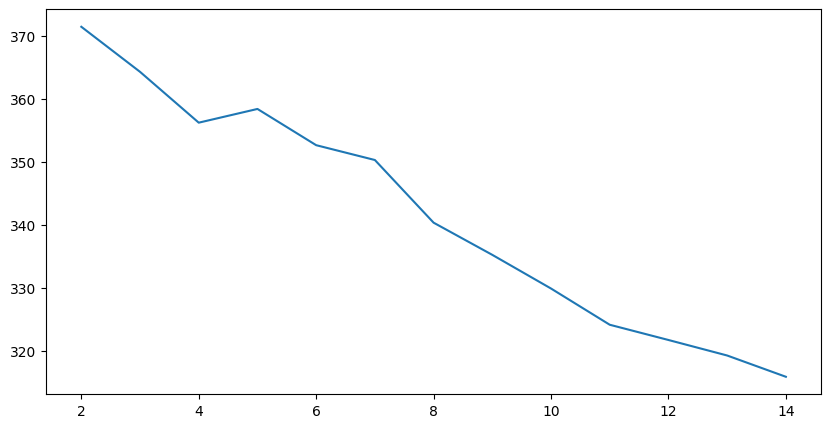

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,5))
plt.plot(range(2,15),inertia)

silhouette score


In [26]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np

sampled_scores = []
sample_size = 5000

if x.shape[0] > sample_size:
    random_indices = np.random.choice(x.shape[0], sample_size, replace=False)
    x_sampled = x[random_indices]
else:
    x_sampled = x

print(f"Calculating silhouette scores on a sample of {x_sampled.shape[0]} data points...")

for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    label_sampled = km.fit_predict(x_sampled)


    if len(np.unique(label_sampled)) > 1:
        score = silhouette_score(x_sampled, label_sampled)
        sampled_scores.append(score)
        print(f"Clusters (K) = {k} | Sampled Silhouette Score = {score:.4f}")
    else:
        print(f"Clusters (K) = {k} | Not enough unique labels for silhouette score (sampled data).")
        sampled_scores.append(None)




Calculating silhouette scores on a sample of 420 data points...
Clusters (K) = 2 | Sampled Silhouette Score = 0.0230
Clusters (K) = 3 | Sampled Silhouette Score = 0.0313
Clusters (K) = 4 | Sampled Silhouette Score = 0.0354
Clusters (K) = 5 | Sampled Silhouette Score = 0.0455
Clusters (K) = 6 | Sampled Silhouette Score = 0.0497
Clusters (K) = 7 | Sampled Silhouette Score = 0.0556
Clusters (K) = 8 | Sampled Silhouette Score = 0.0584
Clusters (K) = 9 | Sampled Silhouette Score = 0.0703
Clusters (K) = 10 | Sampled Silhouette Score = 0.0680
Clusters (K) = 11 | Sampled Silhouette Score = 0.0811
Clusters (K) = 12 | Sampled Silhouette Score = 0.0771
Clusters (K) = 13 | Sampled Silhouette Score = 0.0866
Clusters (K) = 14 | Sampled Silhouette Score = 0.0901


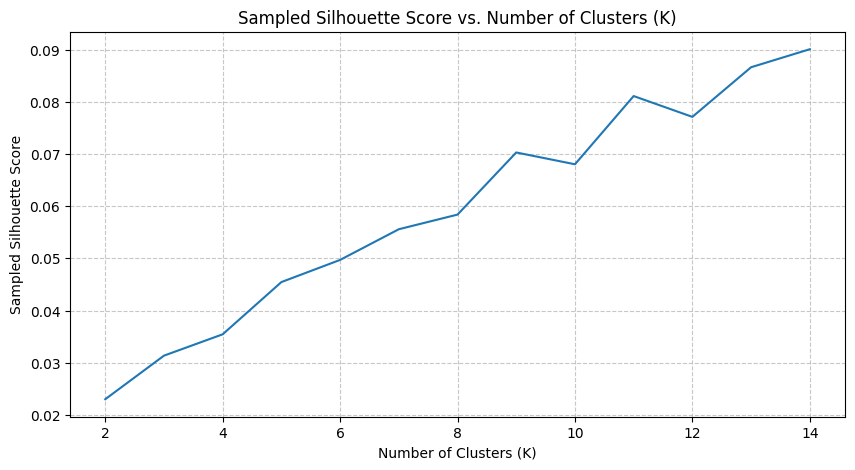

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(2, 15), sampled_scores)
plt.title('Sampled Silhouette Score vs. Number of Clusters (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sampled Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


KMeans clustering


In [28]:
kmeans = KMeans(n_clusters=14 ,random_state=42, n_init = 10)
df['Cluster'] = kmeans.fit_predict(x)


In [29]:
df.iloc[25:55]

,title,description,skills,job_text,Cluster
25,Data Scientist Optimization,Tiger Analytics is looking for experienced Dat...,"['Optimization (integer programming, mixed int...",data scientist optimization tiger analytics lo...,3
26,Senior Director Data Science R,Why We Work at Dun & Bradstreet Dun & Bradstre...,['Machine Learning' 'AI' 'Python' 'PySpark' 'S...,senior director data science r work dun bradst...,13
27,Data Science Director,Altoida is a pioneer in developing digital bio...,['Generative ML methods' 'Discriminative ML me...,data science director altoida pioneer developi...,7
28,Data Scientist Senior Geo,About Veho Veho is the post-purchase experienc...,['Statistical modeling' 'Machine learning tech...,data scientist senior geo veho veho post purch...,4
29,Data Scientist Senior Experimentation,About Veho Veho is the post-purchase experienc...,['Statistical modeling' 'Machine learning' 'SQ...,data scientist senior experimentation veho veh...,4
30,Data Scientist Senior Customer Client,About Veho Veho is the post-purchase experienc...,['Statistical modeling' 'Machine learning tech...,data scientist senior customer client veho veh...,4
31,Data Scientist Product Analyst Marketplace,About Veho Veho is the post-purchase experienc...,['Statistical modeling' 'Machine learning tech...,data scientist product analyst marketplace veh...,4
32,Data Scientist Services,StreetLight pioneered the use of Big Data anal...,['Python' 'pandas' 'NumPy' 'SciPy' 'scikit-lea...,data scientist service streetlight pioneered u...,7
33,Data Scientist International,We are looking for problem solvers with master...,['Analytics' 'Statistics' 'Machine Learning (u...,data scientist international looking problem s...,13
34,Principal Data Scientist Search And Personaliz...,"Principal Data Scientist, Search and Personali...",['Search algorithms' 'Personalization algorith...,principal data scientist search personalizatio...,13


In [30]:
df['skills'] = df['skills'].astype(str).str.replace(r"[\[\]'\"']", "", regex=True)

In [31]:
df.iloc[670:680]

,title,description,skills,job_text,Cluster


In [32]:
df.Cluster.unique()

array([ 7, 13,  0,  4,  6,  3, 10, 12,  2,  1,  9,  5, 11,  8],
      dtype=int32)

In [33]:
df.Cluster.value_counts()

,count
Cluster,
7,147
13,74
4,69
6,37
9,14
1,14
2,11
12,10
3,9


In [34]:

cluster_lists = {}

for i in range(15):
  cluster_lists[i] = df[df['Cluster'] == i]['title'].tolist()



In [35]:
print("Cluster 0 Title")
for idx, title in enumerate(cluster_lists[0],1):
  print(f"{idx}. {title}")

Cluster 0 Title
1. Sr Staff Data Scientist Ecosystem
2. Staff Data Scientist Growth
3. Staff Data Scientist Browse Discovery
4. Sr Data Scientist Search
5. Sr Data Scientist Growth
6. Data Scientist Marketing
7. Data Scientist


In [36]:
print(f"=== FULL LIST OF TITLES FOR CLUSTER 1 ({len(cluster_lists[1])} total) ===")
for idx, title in enumerate(cluster_lists[1], 1):
    print(f"{idx}. {title}")

=== FULL LIST OF TITLES FOR CLUSTER 1 (14 total) ===
1. Decision Science Analyst Senior
2. Senior Decision Analyst
3. Decision Science Analyst I
4. Data Scientist Senior
5. Data Scientist Lead
6. Decision Science Analyst Ii Machine Learning Remote Work Available
7. Decision Science Analyst Lead Marketing
8. Decision Science Analyst Senior Pricing Modeling
9. Decision Science Analyst I Adobe Analytics Remote Work Available
10. Data Scientist Senior Omnichannel
11. Decision Science Lead Marketing
12. Data Scientist Lead Computer Vision
13. Data Scientist Lead
14. Data Scientist I


In [37]:
print("Cluster 2 Titles")
for idx, title in enumerate(cluster_lists[2],1):
  print(f'{idx}. {title}')

Cluster 2 Titles
1. Senior Data Scientist Machine Learning Nlp
2. Senior Data Scientist Analytics Messaging Experience
3. Senior Data Scientist Analytics Messaging Experience
4. Senior Data Scientist Causal Inference
5. Senior Data Scientist Analytics Product Marketing
6. Data Scientist Analytics Product Marketing
7. Data Science Manager
8. Data Science Manager Premium Products
9. Senior Data Scientist Machine Learning Growth
10. Data Science Manager Growth
11. Senior Data Scientist Machine Learning Ecosystems Servers


In [38]:
print("CLuster 3 Title")
for idx, title in enumerate(cluster_lists[3],1):
  print(f'{idx}. {title}')

CLuster 3 Title
1. Data Scientist Optimization
2. Lead Data Scientist Simulation
3. Senior Data Scientist Reinforcement Learning
4. Data Scientist Phd
5. Data Scientist
6. Data Scientist Machine Learning Computer Vision
7. Senior Data Scientist Tx
8. Data Scientist Bfs
9. Data Scientist


In [39]:
print("CLuster 4 Title")
for idx, title in enumerate(cluster_lists[4],1):
  print(f'{idx}. {title}')

CLuster 4 Title
1. Research Scientist Responsible Ai
2. Principal Data Scientist Operations Research
3. Data Scientist Senior Geo
4. Data Scientist Senior Experimentation
5. Data Scientist Senior Customer Client
6. Data Scientist Product Analyst Marketplace
7. Data Science Manager
8. Data Scientist Resilience Modeling
9. Data Scientist I
10. Data Scientist
11. Senior Full Stack Data Scientist
12. Lead Advanced Analytics Trust Safety
13. Staff Research Scientist
14. Product Data Scientist Ranking Homes
15. Product Data Scientist
16. Associate Research Scientist
17. Sr Data Scientist Customer Insights Portal
18. Data Scientist Iii
19. Sr Data Scientist
20. Research Scientist
21. Senior Data Scientist
22. Vp Data Science
23. Senior Data Scientist City Success
24. Staff Data Scientist Machine Learning
25. Senior Manager Data Science
26. Senior Data Scientist
27. Senior Data Scientist
28. Senior Ml Engineer Sr Data Scientist
29. Data Scientist New Grad
30. Data Scientist Product Community T

In [40]:
print("CLuster 5 Title")
for idx, title in enumerate(cluster_lists[5],1):
  print(f'{idx}. {title}')

CLuster 5 Title
1. Senior Applied Scientist I Knowledge Base
2. Data Scientist Product Analytics
3. Data Scientist Product Analytics
4. Senior Data Scientist Trust Safety
5. Senior Data Scientist Product Analytics
6. Senior Data Scientist Forecasting
7. Staff Applied Scientist I Core Fulfillment
8. Senior Applied Scientist I Core Fulfillment


In [41]:
print("CLuster 6 Title")
for idx, title in enumerate(cluster_lists[6],1):
  print(f'{idx}. {title}')

CLuster 6 Title
1. Data Scientist Product
2. Data Scientist Marketing
3. Data Scientist Finance
4. Data Science And Analytics Manager Streaming Product
5. Data Science Lead
6. Lead Data Scientist Product Growth
7. Data Science Team Lead
8. Marketing Analytics Data Science Senior Manager
9. Senior Data Scientist
10. Data Scientist
11. Staff Data Scientist
12. Data Science Manager Help Journey
13. Senior Data Scientist Product Analytics
14. Data Scientist Product Analytics
15. Senior Data Scientist India
16. Staff Data Scientist
17. Senior Data Scientist Product
18. Embedded Data Scientist Evangelist
19. Data Scientist
20. Senior Or Staff Data Scientist Spotify Advertising
21. Data Scientist Spotify Advertising
22. Senior Data Scientist Performance Platform
23. Data Scientist Europe
24. Senior Data Scientist
25. Data Scientist
26. Sr Manager Data Science Analytics
27. Senior Data Scientist
28. Senior Data Scientist Experience
29. Data Scientist Experience
30. Senior Data Scientist Analyt

In [42]:
print("CLuster 7 Title")
for idx, title in enumerate(cluster_lists[7], 1):
  print(f'{idx}. {title}')


CLuster 7 Title
1. Data Science Director
2. Senior Data Scientist
3. Senior Data Scientist
4. Lead Data Scientist
5. Senior Data Scientist I Nlp
6. Principal Data Scientist
7. Senior Data Scientist
8. Machine Learning Scientist Generative Ai
9. Data Science Director
10. Data Scientist Services
11. Lead Data Scientist
12. Senior Data Scientist
13. Senior Data Scientist
14. Data Scientist
15. Sr Data Scientist
16. Data Scientist
17. Senior Data Scientist
18. Senior Manager Data Science
19. Sr Data Scientist
20. Data Scientist
21. Director Of Applied Data Science Media Insights
22. Junior Data Scientist
23. Senior Data Scientist
24. Data Scientist
25. Senior Data Scientist Us
26. Senior Data Scientist Lead
27. Data Scientist
28. Senior Data Scientist
29. Lead Data Scientist
30. Data Scientist
31. Senior Ai Engineer Ai Scientist
32. Manager Of Computer Vision
33. Lead Data Scientist Growth Cx
34. Data Scientist
35. Senior Data Scientist
36. Senior Ml Nlp Data Scientist
37. Lead Data Scient

In [43]:
print("CLuster 8 Title")
for idx, title in enumerate(cluster_lists[8],1):
  print(f'{idx}. {title}')

CLuster 8 Title
1. Data Science Manager Trust
2. Senior Data Scientist Shop
3. Staff Lead Data Scientist
4. Data Science Manager
5. Lead Data Scientist Europe
6. Lead Data Scientist Shop Europe
7. Data Science Manager
8. Senior Data Scientist Shop Europe


In [44]:
print("CLuster 9 Title")
for idx, title in enumerate(cluster_lists[9],1):
  print(f'{idx}. {title}')

CLuster 9 Title
1. Data Scientist Enterprise Marketing
2. Senior Marketing Data Scientist Monetization
3. Community Marketing Data Scientist
4. Senior Marketing Data Scientist Agile Devops
5. Senior Email Marketing Data Scientist
6. Senior Marketing Data Scientist Buyer Experience
7. Senior Principal Data Scientist Pst
8. Senior Data Scientist Product Analytics
9. Senior Data Scientist Product Analytics Halp
10. Data Scientist Enterprise Marketing
11. Manager Data Science Product Analytics
12. Senior Marketing Data Scientist Partnerships
13. Senior Data Scientist Customer Analytics
14. Principal Technical Data Scientist


In [45]:
print("CLuster 10 Title")
for idx, title in enumerate(cluster_lists[10],1):
  print(f'{idx}. {title}')

CLuster 10 Title
1. Senior Product Data Scientist
2. Data Scientist Lead Square F S
3. Staff Data Scientist Model Risk Management
4. Senior Product Data Scientist
5. Senior Data Scientist Go To Market Automation
6. Data Scientist Customer Identity Access Management
7. Senior Data Scientist Ecommerce
8. Senior Data Scientist Commerce Platform Inventory


In [46]:
print("CLuster 11 Title")
for idx, title in enumerate(cluster_lists[11],1):
  print(f'{idx}. {title}')

CLuster 11 Title
1. Senior Data Scientist For Risk
2. Senior Data Scientist For Risk
3. Senior Data Scientist Risk
4. Data Scientist Growth


In [47]:
print("CLuster 12 Title")
for idx, title in enumerate(cluster_lists[12],1):
  print(f'{idx}. {title}')

CLuster 12 Title
1. Senior Product Manager Ads Contextual Intelligence
2. Data Scientist Growth Analytics Channels
3. Sr Data Scientist Ads Experimentation Analytics
4. Sr Data Scientist Analytics Growth Retention
5. Sr Data Scientist Machine Learning Search
6. Senior Data Scientist International Growth
7. Senior Data Scientist International Analytics
8. Senior Data Scientist Analytics Ecosystem
9. Senior Data Scientist Dev Platform Analytics
10. Senior Data Scientist Search Analytics


In [48]:
for idx, title in enumerate(cluster_lists[13], 1):
  print(f'{idx}. {title}')

1. Staff Data Scientist
2. Data Scientist
3. Cybersecurity Data Scientist Manager
4. Senior Data Scientist
5. Data Scientist
6. Forecast Analyst Retail Call Center Workforce Management
7. Lead Data Scientist Retail Payer Analytics
8. Senior Director Data Science R
9. Data Scientist International
10. Principal Data Scientist Search And Personalization United States
11. Data Scientist
12. Principal Data Scientist Search And Personalization Canada
13. Senior Data Scientist
14. Senior Data Scientist Clinical Research Commercial Pharma Analytics
15. Data Science Manager
16. Senior Data Scientist
17. Associate Director Product Analytics And Data Science
18. Senior Healthcare Analytics And Research Consultant
19. Quantitative Risk Analyst Ii
20. Senior Data Science Manager
21. Data Scientist Analytics
22. Senior Data Scientist Analytics
23. Experienced Data Scientist Analytics
24. Staff Data Scientist
25. Data Scientist
26. Assistant Director Advanced Analytics
27. Senior Data Scientist
28. S

In [49]:
df.Cluster.unique()

array([ 7, 13,  0,  4,  6,  3, 10, 12,  2,  1,  9,  5, 11,  8],
      dtype=int32)

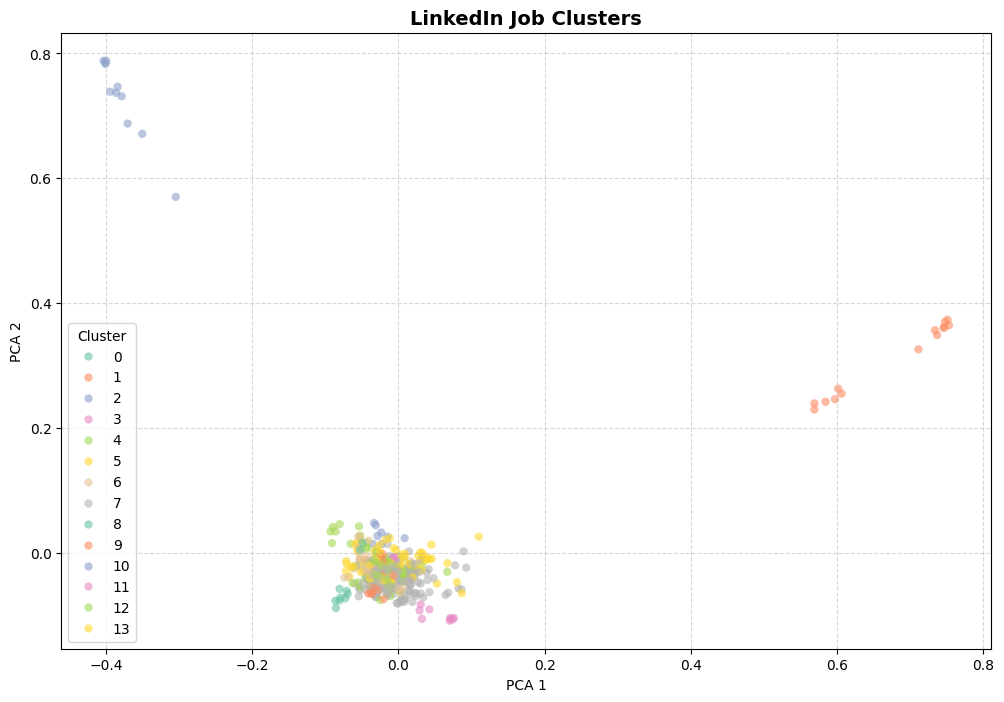

In [50]:
from sklearn.decomposition import PCA
import seaborn as sns
pca = PCA(n_components=2)
pca_fit = pca.fit_transform(x.toarray())

df['pca_x'] = pca_fit[:, 0]
df['pca_y'] = pca_fit[:,1]

plt.figure(figsize=(12,8))

sns.scatterplot(

    x = 'pca_x',
    y = 'pca_y',
    hue  = 'Cluster',
    data = df,
    palette = 'Set2',
    alpha = 0.6,
    edgecolor = 'none'
)

plt.title('LinkedIn Job Clusters', fontsize = 14, fontweight = 'bold')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True, linestyle='--',alpha = 0.5)
plt.show()

In [51]:
df.Cluster.unique()

array([ 7, 13,  0,  4,  6,  3, 10, 12,  2,  1,  9,  5, 11,  8],
      dtype=int32)

In [52]:
cluster_to_department_map = {
    0: "IT Infrastructure & System Administration",
    1: "Customer Service & BPO Operations",
    2: "Data Science, Analytics & Research",
    3: "Finance & Accounting",
    4: "Web Development & Design",
    5: "Academic & Research Positions",
    6: "Software Development & Engineering",
    7: "Advanced Data Science & Machine Learning ",
    8: " Sales & Business Development",
    9: "Marketing & Communications",
    10: "General Administration & Technical Support",
    11:"Manufacturing, Production & Quality Control " ,
    12: "IT Product Development & Architecture ",
    13: "HR Operations & Staffing"
}

df['Job_Family'] = df['Cluster'].map(cluster_to_department_map)

print("--- Sample of Unified Mappings ---")
print(df[['title', 'Job_Family']].sample(10))

--- Sample of Unified Mappings ---
                                          title  \
340                      Data Scientist Product   
256                              Data Scientist   
189                                Data Science   
163             Director Data Science Analytics   
178  Senior Data Scientist International Growth   
14                     Principal Data Scientist   
382                              Data Scientist   
131                           Sr Data Scientist   
337                       Senior Data Scientist   
367                       Senior Data Scientist   

                                    Job_Family  
340         Software Development & Engineering  
256  Advanced Data Science & Machine Learning   
189  Advanced Data Science & Machine Learning   
163  Advanced Data Science & Machine Learning   
178     IT Product Development & Architecture   
14   Advanced Data Science & Machine Learning   
382  Advanced Data Science & Machine Learning   
131  Advanc

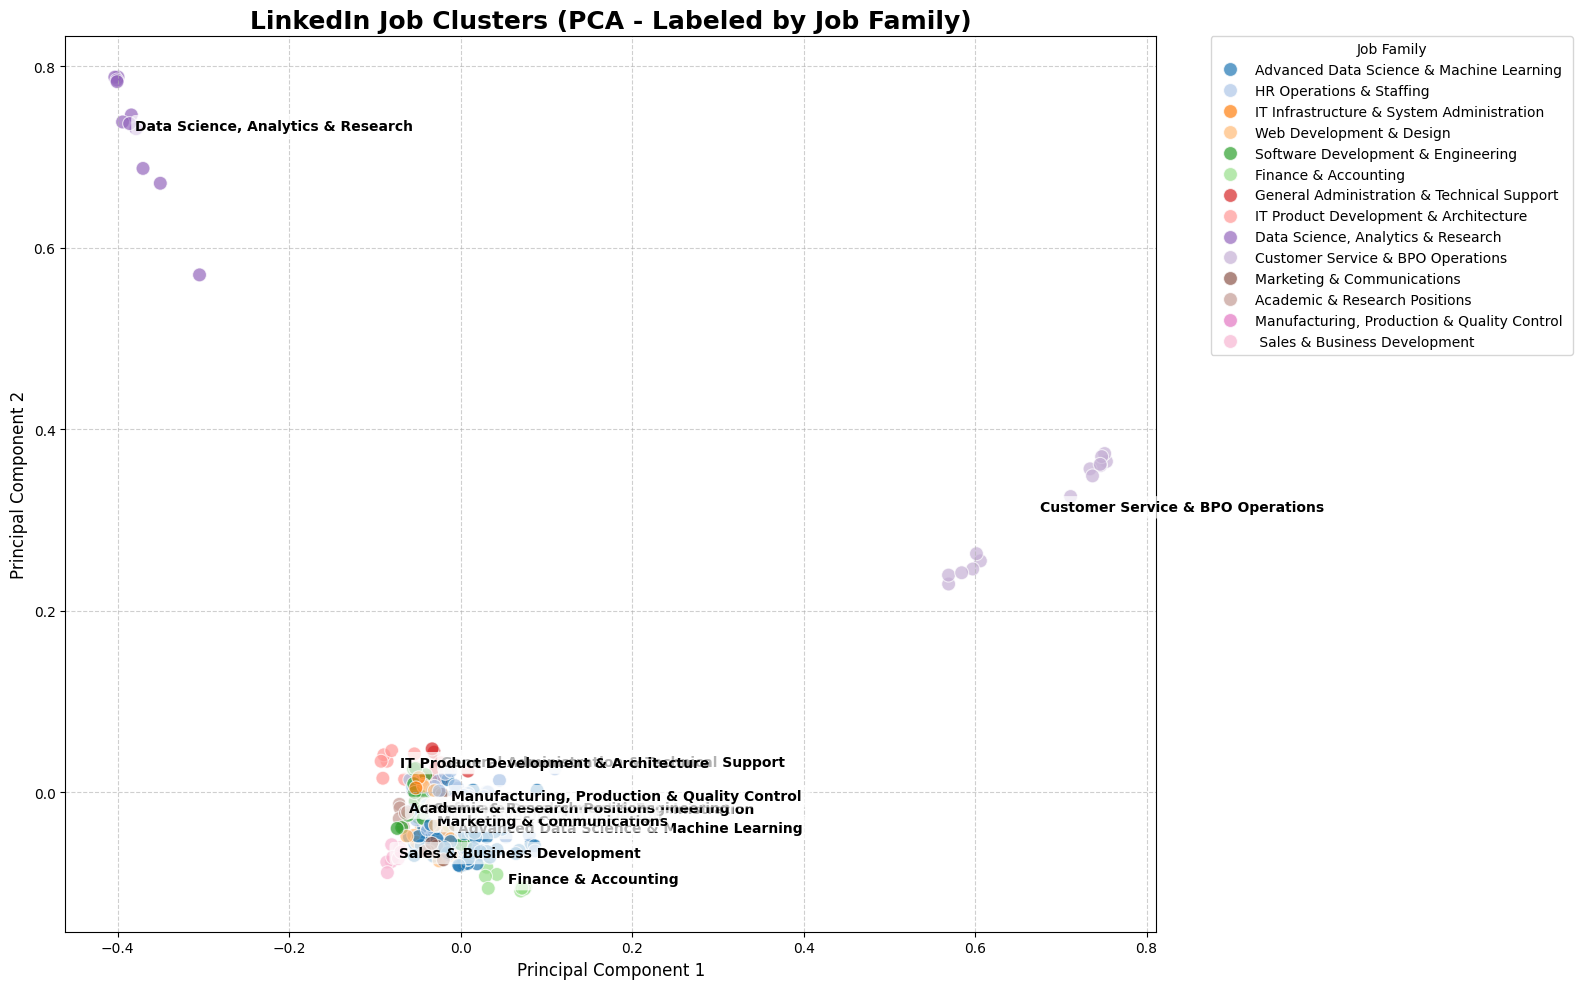

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
sns.scatterplot(
    x='pca_x',
    y='pca_y',
    hue='Job_Family',
    data=df,
    palette='tab20',
    alpha=0.7,
    s=100,
    edgecolor='w'
)

for job_family in df['Job_Family'].unique():
    subset = df[df['Job_Family'] == job_family]
    centroid_x = subset['pca_x'].mean()
    centroid_y = subset['pca_y'].mean()
    plt.text(centroid_x, centroid_y, job_family,
             fontsize=10, weight='bold',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

plt.title('LinkedIn Job Clusters (PCA - Labeled by Job Family)', fontsize=18, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Job Family', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Move legend outside
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [54]:
df.iloc[20:25]

,title,description,skills,job_text,Cluster,pca_x,pca_y,Job_Family
20,Principal Data Scientist Operations Research,About Veho Veho is the post-purchase experienc...,Operations Research Linear Programming (LP)\n ...,principal data scientist operation research ve...,4,-0.006521,-0.022830,Web Development & Design
21,Machine Learning Scientist Generative Ai,Passionate about precision medicine and advanc...,"Generative AI models (GANs, VAEs) LLM (Large L...",machine learning scientist generative ai passi...,7,-0.021865,-0.035692,Advanced Data Science & Machine Learning
22,Data Scientist Product,What is Underdog? Founded by a team of industr...,Analytics Statistical solutions Quantitative d...,data scientist product underdog founded team i...,6,-0.020372,-0.012150,Software Development & Engineering
23,Data Scientist Marketing,What is Underdog? Founded by a team of industr...,Marketing analytics Large dataset analysis\n D...,data scientist marketing underdog founded team...,6,0.001952,-0.010720,Software Development & Engineering
24,Data Scientist Finance,What is Underdog? Founded by a team of industr...,Experience analyzing large datasets SQL Python...,data scientist finance underdog founded team i...,6,0.016587,-0.013286,Software Development & Engineering


In [55]:
print(df['skills'].iloc[0])

Generative ML methods Discriminative ML methods
 Contrastive ML methods Classification techniques
 Gradient boosting techniques Knowledge discovery Causal inference
 Applied mathematics
 Statistics (Bayesian, Multi-Objective Optimization, Topological Data Analysis)
 AI Machine Learning Data quality management
 Data validation procedures Data curation Data documentation
 Data protection Data storage Model output calibration
 Data security protocols Python (object-oriented development)
 Scientific Python packages Statistical Python packages SQL
 Programming languages Quality Management Systems
 Healthcare data standards HIPAA regulations


In [56]:
programming_languages = [
    "python","java","c","c++","c#","javascript","typescript","php",
    "ruby","go","rust","kotlin","swift","r","scala","perl","matlab",
    "sql","pl sql","bash","shell scripting","powershell"
]

data_science = [
    "machine learning","deep learning","artificial intelligence",
    "data science","data analysis","predictive analytics",
    "statistical analysis","nlp","computer vision",
    "reinforcement learning","feature engineering",
    "time series","classification","regression",
    "clustering","recommendation systems","forecasting",
    "sentiment analysis","generative ai","llm","rag"
]


ml_frameworks = [
    "tensorflow","keras","pytorch","scikit learn","xgboost",
    "lightgbm","catboost","opencv","huggingface","transformers",
    "langchain","llamaindex"
]

python_libraries = [
    "numpy","pandas","matplotlib","seaborn",
    "plotly","scipy","statsmodels",
    "streamlit","flask","fastapi"
]

databases = [
    "mysql","postgresql","mongodb","oracle",
    "sqlite","sql server","redis","cassandra",
    "firebase","supabase","neo4j","elasticsearch"
]

business_intelligence = [
    "power bi","tableau","looker","qlik sense",
    "excel","google sheets","dashboard development"
]

cloud = [
    "aws","azure","gcp","docker",
    "kubernetes","terraform","ansible",
    "jenkins","github actions","ci cd"
]

backend = [
    "spring boot","hibernate","node js",
    "express","django","flask","fastapi",
    "rest api","graphql","microservices"
]

frontend = [
    "react","angular","vue","html","css",
    "bootstrap","tailwind css","next js",
    "vite","redux"
]

mobile = [
    "android","ios","flutter",
    "react native","swift","kotlin"
]

devops = [
    "git","github","gitlab",
    "docker","kubernetes",
    "jenkins","terraform",
    "linux","nginx"
]

networking = [
    "tcp ip","routing","switching",
    "network security","firewall",
    "vpn","dns","dhcp"
]

cybersecurity = [
    "penetration testing","ethical hacking",
    "owasp","siem","soc",
    "vulnerability assessment",
    "incident response"
]

finance = [
    "financial analysis",
    "accounting",
    "budgeting",
    "risk management",
    "investment analysis",
    "auditing"
]

hr = [
    "recruitment",
    "talent acquisition",
    "payroll",
    "employee engagement",
    "performance management",
    "hr analytics"
]

marketing = [
    "seo","sem","google analytics",
    "social media marketing",
    "content marketing",
    "email marketing"
]

soft_skills = [
    "communication",
    "leadership",
    "problem solving",
    "teamwork",
    "critical thinking",
    "time management",
    "presentation",
    "project management"
]




In [57]:
skills_dictionary = (
    programming_languages +
    data_science +
    ml_frameworks +
    python_libraries +
    databases +
    business_intelligence +
    cloud +
    backend +
    frontend +
    mobile +
    devops +
    networking +
    cybersecurity +
    finance +
    hr +
    marketing +
    soft_skills
)

skills_dictionary = sorted(set(skills_dictionary))

In [58]:
import re

def extract_skills(text, skills_dictionary):

    text = str(text).lower()

    found = []

    for skill in skills_dictionary:

        pattern = r'\b' + re.escape(skill) + r'\b'

        if re.search(pattern, text):

            found.append(skill)

    return found

In [59]:
df["Extracted_Skills"] = (
    df["skills"].fillna("") +
    " " +
    df["description"].fillna("")
).apply(
    lambda x: extract_skills(
        x,
        skills_dictionary
    )
)

In [60]:
df.head()

,title,description,skills,job_text,Cluster,pca_x,pca_y,Job_Family,Extracted_Skills
0,Data Science Director,Altoida is a pioneer in developing digital bio...,Generative ML methods Discriminative ML method...,data science director altoida pioneer developi...,7,0.023750,-0.069048,Advanced Data Science & Machine Learning,"[classification, communication, data analysis,..."
1,Senior Data Scientist,Veeva Systems is a mission-driven organization...,Natural Language Processing (NLP) Machine Lear...,senior data scientist veeva system mission dri...,7,-0.026093,-0.057385,Advanced Data Science & Machine Learning,"[artificial intelligence, aws, azure, bash, co..."
2,Staff Data Scientist,"To get the best candidate experience, please c...",SQL Programming language for data analysis (e....,staff data scientist get best candidate experi...,13,0.001537,-0.019417,HR Operations & Staffing,"[data analysis, leadership, machine learning, ..."
3,Sr Staff Data Scientist Ecosystem,About Pinterest: Millions of people across the...,Quantitative modeling Experimentation design a...,sr staff data scientist ecosystem pinterest mi...,0,-0.039520,-0.039239,IT Infrastructure & System Administration,"[communication, data analysis, deep learning, ..."
4,Staff Data Scientist Growth,About Pinterest: Millions of people across the...,Scientific Methods Web-scale Data Analysis Pyt...,staff data scientist growth pinterest million ...,0,-0.042334,-0.020513,IT Infrastructure & System Administration,"[communication, data analysis, leadership, pyt..."


Extract clusters

In [61]:
cluster_jobs = {}

for cluster_id in sorted(df['Cluster'].unique()):
  cluster_jobs[cluster_id] = df[df['Cluster'] == cluster_id].copy()




In [62]:
print(list(cluster_jobs))

[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13)]


Extract SKills from Specific clusters

In [63]:
cluster_skills = {}

for cluster_id, cluster_df in cluster_jobs.items():
  skills_list= cluster_df['Extracted_Skills'].dropna().tolist()
  cluster_skills[cluster_id] = skills_list



In [64]:
print(cluster_skills.keys())


dict_keys([np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13)])


In [65]:
print(cluster_skills[0][:3])

[['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'leadership', 'python', 'r', 'seo', 'sql'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow']]


In [66]:
cluster_skills.items()

dict_items([(np.int32(0), [['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'leadership', 'python', 'r', 'seo', 'sql'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['predictive analytics', 'python', 'pytorch', 'sql', 'statistical analysis', 'tensorflow'], ['predictive analytics', 'python', 'pytorch', 'sql', 'tensorflow']]), (np.int32(1), [['c', 'communication', 'data analysis', 'data science', 'python', 'sql'], ['communication', 'data analysis', 'data science', 'python', 'sq

In [67]:
# import re

# processed_skills = {}

# for cluster_id, skills in cluster_skills.items():

#     sentences = []

#     for skill_text in skills:

#         skill_text = str(skill_text).lower()


#         skill_text = skill_text.replace("\n", ",")


#         skill_text = skill_text.replace("/", ",")


#         tokens = []

#         for skill in skill_text.split(","):

#             skill = skill.strip()

#             if len(skill) > 2:
#                 tokens.append(skill)

#         sentences.append(tokens)

#     processed_skills[cluster_id] = sentences

In [68]:
import ast

processed_skills = {}

for cluster_id, skills_list in cluster_skills.items():

    sentences = []

    for skill in skills_list:


        if isinstance(skill, str):
            skill = ast.literal_eval(skill)

        tokens = []

        for s in skill:

            s = s.lower().strip()

            s = s.replace("/", " ")

            if s:
                tokens.append(s)

        sentences.append(tokens)

    processed_skills[cluster_id] = sentences

In [69]:
print("Cluster 0")

if 0 in processed_skills:
    print(processed_skills[0][:5])
elif '0' in processed_skills:
    print(processed_skills['0'][:5])
else:
    print("Available keys are:", list(processed_skills.keys()))

Cluster 0
[['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'leadership', 'python', 'r', 'seo', 'sql'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow']]


In [70]:

for cluster_id in processed_skills:

    print(
        f"Cluster {cluster_id} :",
        len(processed_skills[cluster_id]),
        "Jobs"
    )

Cluster 0 : 7 Jobs
Cluster 1 : 14 Jobs
Cluster 2 : 11 Jobs
Cluster 3 : 9 Jobs
Cluster 4 : 69 Jobs
Cluster 5 : 8 Jobs
Cluster 6 : 37 Jobs
Cluster 7 : 147 Jobs
Cluster 8 : 8 Jobs
Cluster 9 : 14 Jobs
Cluster 10 : 8 Jobs
Cluster 11 : 4 Jobs
Cluster 12 : 10 Jobs
Cluster 13 : 74 Jobs


In [71]:
all_skills = []

for cluster_sentences in processed_skills.values():

    all_skills.extend(cluster_sentences)

print(len(all_skills))

420


In [72]:
print(all_skills[:5])

[['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'leadership', 'python', 'r', 'seo', 'sql'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow'], ['communication', 'data analysis', 'deep learning', 'forecasting', 'leadership', 'machine learning', 'python', 'pytorch', 'r', 'sql', 'tensorflow']]


In [73]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.1 MB/s eta 0:00:00


In [74]:
from gensim.models import Word2Vec

word2vec = Word2Vec(
    sentences = all_skills,
    vector_size = 100,
    window = 5,
    min_count = 2,
    sg = 1,
    workers=4,
    epochs = 30,
    seed  =42
    )


In [75]:
word2vec.save(
    "skills_word2vec.model"
)

In [76]:
word2vec.wv.most_similar('machine learning',topn=20)

[('php', 0.9939351081848145),
 ('sql server', 0.9934177994728088),
 ('google analytics', 0.9933488965034485),
 ('data analysis', 0.9933189153671265),
 ('critical thinking', 0.9928867816925049),
 ('clustering', 0.9928612112998962),
 ('performance management', 0.992681622505188),
 ('excel', 0.9924948811531067),
 ('cassandra', 0.9923787713050842),
 ('payroll', 0.992367148399353),
 ('oracle', 0.992289662361145),
 ('leadership', 0.9922494292259216),
 ('android', 0.9921972155570984),
 ('terraform', 0.9918649196624756),
 ('budgeting', 0.9916719794273376),
 ('time management', 0.9910891056060791),
 ('swift', 0.9910884499549866),
 ('financial analysis', 0.9909016489982605),
 ('talent acquisition', 0.9908761978149414),
 ('redis', 0.9907538890838623)]

**Testing The model**


In [77]:
from collections import Counter

top20_cluster_skills = {}

for cluster_id, sentences in processed_skills.items():

    all_skills = []

    # Flatten all skills
    for sentence in sentences:
        all_skills.extend(sentence)

    # Count frequency
    skill_counter = Counter(all_skills)

    # Extract Top 20
    top20 = skill_counter.most_common(20)

    top20_cluster_skills[cluster_id] = top20

In [78]:
for cluster in top20_cluster_skills:

    print(f"\nCluster {cluster}")

    print(top20_cluster_skills[cluster])


Cluster 0
[('python', 7), ('sql', 7), ('pytorch', 6), ('tensorflow', 6), ('communication', 5), ('leadership', 5), ('r', 5), ('data analysis', 4), ('deep learning', 4), ('forecasting', 4), ('machine learning', 4), ('predictive analytics', 2), ('seo', 1), ('statistical analysis', 1)]

Cluster 1
[('data analysis', 14), ('data science', 14), ('c', 12), ('communication', 11), ('python', 11), ('sql', 10), ('machine learning', 8), ('regression', 7), ('clustering', 6), ('statistical analysis', 6), ('computer vision', 5), ('java', 5), ('perl', 5), ('predictive analytics', 5), ('ruby', 5), ('nlp', 4), ('deep learning', 3), ('forecasting', 2), ('leadership', 2), ('r', 1)]

Cluster 2
[('sql', 11), ('leadership', 9), ('python', 8), ('looker', 8), ('tableau', 8), ('r', 7), ('machine learning', 6), ('communication', 6), ('data science', 4), ('sentiment analysis', 2), ('generative ai', 1), ('nlp', 1), ('pytorch', 1), ('reinforcement learning', 1), ('tensorflow', 1), ('statistical analysis', 1), ('das

In [79]:
top20_skill_names = {}

for cluster, skills in top20_cluster_skills.items():

    top20_skill_names[cluster] = [
        skill
        for skill, freq in skills
    ]

In [80]:
print(top20_skill_names[0])

['python', 'sql', 'pytorch', 'tensorflow', 'communication', 'leadership', 'r', 'data analysis', 'deep learning', 'forecasting', 'machine learning', 'predictive analytics', 'seo', 'statistical analysis']


In [81]:
resume = """
Anand is a Computer Science student with strong knowledge of
Python, SQL, Pandas, NumPy, Machine Learning, TensorFlow,
Power BI and Git.
Worked on Deep Learning and Computer Vision projects.
"""

In [82]:
candidate_skills = set(extract_skills(resume, skills_dictionary))

In [83]:
#  0: "IT Infrastructure & System Administration",
#     1: "Customer Service & BPO Operations",
#     2: "Data Science, Analytics & Research",
#     3: "Finance & Accounting",
#     4: "Web Development & Design",
#     5: "Academic & Research Positions",
#     6: "Software Development & Engineering",
#     7: "Advanced Data Science & Machine Learning ",
#     8: " Sales & Business Development",
#     9: "Marketing & Communications",
#     10: "General Administration & Technical Support",
#     11:"Manufacturing, Production & Quality Control " ,
#     12: "IT Product Development & Architecture ",
#     13: "HR Operations & Staffing"

In [84]:
print(candidate_skills)

{'machine learning', 'git', 'sql', 'computer vision', 'numpy', 'python', 'pandas', 'power bi', 'tensorflow', 'deep learning'}


In [85]:
cluster_id = 7

required_skills = top20_skill_names[cluster_id]

In [86]:
matched = []

missing = []

for skill in required_skills:

    if skill in candidate_skills:

        matched.append(skill)

    else:

        missing.append(skill)

In [87]:
print("Matched Skills")
print(matched)

print("\nMissing Skills")
print(missing)

Matched Skills
['python', 'machine learning', 'sql', 'deep learning', 'tensorflow', 'pandas']

Missing Skills
['data science', 'communication', 'r', 'data analysis', 'leadership', 'aws', 'nlp', 'pytorch', 'regression', 'tableau', 'classification', 'clustering', 'gcp', 'artificial intelligence']


In [88]:
related = []
true_missing = []

threshold = 0.70

for required in missing:

    found = False

    for user_skill in candidate_skills:

        if (
            required in word2vec.wv
            and
            user_skill in word2vec.wv
        ):

            similarity = word2vec.wv.similarity(
                required,
                user_skill
            )

            if similarity >= threshold:

                related.append({
                    "Required Skill": required,
                    "Known Skill": user_skill,
                    "Similarity": round(similarity,2)
                })

                found = True

                break

    if not found:

        true_missing.append(required)

In [89]:
match_score = (
    len(matched)
    /
    len(required_skills)
)*100

In [90]:
semantic_score = (
    (
        len(matched)
        +
        len(related)
    )
    /
    len(required_skills)
)*100

In [91]:
print("="*60)

print("Target Job Family")

print(df['Job_Family'][df['Cluster']==cluster_id].iloc[0])

print("="*60)

print("Top 20 Required Skills")

print(required_skills)

print("="*60)

print("Candidate Skills")

print(candidate_skills)

print("="*60)

print("Matched Skills")

print(matched)

print("="*60)

print("Related Skills")

for skill in related:

    print(skill)

print("="*60)

print("Missing Skills")

print(true_missing)

print("="*60)

print(f"Exact Match : {match_score:.2f}%")

print(f"Semantic Match : {semantic_score:.2f}%")

Target Job Family
Advanced Data Science & Machine Learning 
Top 20 Required Skills
['python', 'machine learning', 'data science', 'sql', 'communication', 'r', 'data analysis', 'leadership', 'aws', 'deep learning', 'nlp', 'tensorflow', 'pytorch', 'regression', 'tableau', 'pandas', 'classification', 'clustering', 'gcp', 'artificial intelligence']
Candidate Skills
{'machine learning', 'git', 'sql', 'computer vision', 'numpy', 'python', 'pandas', 'power bi', 'tensorflow', 'deep learning'}
Matched Skills
['python', 'machine learning', 'sql', 'deep learning', 'tensorflow', 'pandas']
Related Skills
{'Required Skill': 'data science', 'Known Skill': 'machine learning', 'Similarity': np.float32(0.99)}
{'Required Skill': 'communication', 'Known Skill': 'machine learning', 'Similarity': np.float32(0.99)}
{'Required Skill': 'r', 'Known Skill': 'machine learning', 'Similarity': np.float32(0.98)}
{'Required Skill': 'data analysis', 'Known Skill': 'machine learning', 'Similarity': np.float32(0.99)}
{'

In [92]:
joblib.dump(kmeans, "Kmeans_model.pkl")
files.download('Kmeans_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>